In [1]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics

/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Using device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）

処理済みデータ形状: (19389, 20)
ベクトル次元数: 1088
企業数: 2450, 特許数: 19384

構築完了:
  総ノード数: 21834
  企業数: 2450
  特許数: 19384
  年数: 11
  年度: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
  履歴エッジ数: 27274


In [57]:
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.data import HeteroData

class HeteroVGAEEncoder(nn.Module):
    def __init__(self, corp_in_dim, pat_in_dim, hidden_channels, out_channels):
        super().__init__()
        
        # エラー修正箇所: bipartite(2部グラフ)エッジでは add_self_loops=False が必須
        self.conv1 = HeteroConv({
            ('corp', 'owns', 'patent'): GATConv(corp_in_dim, hidden_channels, heads=2, concat=False, add_self_loops=False),
            ('patent', 'owned_by', 'corp'): GATConv(pat_in_dim, hidden_channels, heads=2, concat=False, add_self_loops=False)
        }, aggr='sum')

        self.conv2 = HeteroConv({
            ('corp', 'owns', 'patent'): GATConv(hidden_channels, hidden_channels, heads=1, concat=False, add_self_loops=False),
            ('patent', 'owned_by', 'corp'): GATConv(hidden_channels, hidden_channels, heads=1, concat=False, add_self_loops=False)
        }, aggr='sum')

        self.mu_layer = nn.ModuleDict({
            'corp': nn.Linear(hidden_channels, out_channels),
            'patent': nn.Linear(hidden_channels, out_channels)
        })
        self.logvar_layer = nn.ModuleDict({
            'corp': nn.Linear(hidden_channels, out_channels),
            'patent': nn.Linear(hidden_channels, out_channels)
        })

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.elu(x) for k, x in x_dict.items()}
        
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {k: F.elu(x) for k, x in x_dict.items()}

        mu = {k: self.mu_layer[k](x) for k, x in x_dict.items()}
        logvar = {k: self.logvar_layer[k](x) for k, x in x_dict.items()}
        return mu, logvar

def to_hetero_data(data, num_corps):
    """Homogeneous DataをHeteroDataに変換。デバイス転送は呼び出し側で行う"""
    h_data = HeteroData()
    h_data['corp'].x = data.x[:num_corps]
    h_data['patent'].x = data.x[num_corps:]
    
    edge_index = data.edge_index
    c2p_mask = (edge_index[0] < num_corps) & (edge_index[1] >= num_corps)
    c2p_edges = edge_index[:, c2p_mask].clone()
    c2p_edges[1] -= num_corps
    
    h_data['corp', 'owns', 'patent'].edge_index = c2p_edges
    h_data['patent', 'owned_by', 'corp'].edge_index = torch.stack([c2p_edges[1], c2p_edges[0]])
    
    h_data['corp'].active_mask = data.active_mask[:num_corps]
    h_data['patent'].active_mask = data.active_mask[num_corps:]
    return h_data

In [58]:
@torch.no_grad()
def compute_ranking_metrics(model, z, edge_index, num_corps, all_true_edges):
    """
    検証データに対する MRR を算出する。
    Bilinearデコーダのスコア計算に準拠。
    """
    model.eval()
    device = z.device
    
    # 検証ターゲット（企業 -> 特許）のエッジのみ抽出
    mask = (edge_index[0] < num_corps) & (edge_index[1] >= num_corps)
    target_edges = edge_index[:, mask]
    
    if target_edges.size(1) == 0:
        return None

    mrr_list = []
    # 計算負荷軽減のため、最大100エッジ程度をサンプリングして評価
    num_eval = min(target_edges.size(1), 100)
    indices = torch.randperm(target_edges.size(1))[:num_eval]
    
    for idx in indices:
        u, v = target_edges[0, idx].item(), target_edges[1, idx].item()
        
        # 1. 正解ペアのスコア
        pos_edge = torch.tensor([[u], [v]], device=device)
        pos_score = model.decode(z, pos_edge).item()
        
        # 2. 負例（ランダムな特許ノード）のスコアを計算
        # 特許ノードの範囲からランダムにサンプリング
        num_patents = model.num_nodes - num_corps
        neg_v = torch.randint(num_corps, model.num_nodes, (100,), device=device)
        
        # (u, neg_v) が正解セットに含まれていないかチェック
        neg_v_list = [nv.item() for nv in neg_v if (u, nv.item()) not in all_true_edges]
        if not neg_v_list: continue
        
        neg_edges = torch.tensor([[u] * len(neg_v_list), neg_v_list], device=device)
        neg_scores = model.decode(z, neg_edges).cpu().numpy()
        
        # 3. 順位の算出
        rank = np.sum(neg_scores >= pos_score) + 1
        mrr_list.append(1.0 / rank)
        
    return {'mrr': np.mean(mrr_list)} if mrr_list else {'mrr': 0.0}

In [60]:
# ============================================================
# セル10 (修正): 高解像度・安定化したPotentialNet
# ============================================================
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        # 空間の解像度を上げるためのランダム周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim
        
        # 層を深くし、Dropoutを加えることで一方向の単純な壁になるのを防ぐ
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh() # 出力を -1 から 1 に制限
        )

    def forward(self, z):
        # 座標 z を高周波に変換することで「島」を作りやすくする
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        with torch.no_grad():
            potentials = self.forward(grid_points)
        
        return X.cpu().numpy(), Y.cpu().numpy(), potentials.view(resolution, resolution).cpu().numpy()

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net, num_corps):
        super().__init__()
        self.potential_net = potential_net
        self.num_corps = num_corps
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # z: [全ノード数, latent_dim]
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # 1. 勾配の逆方向（下り坂）を計算
        velocity = - torch.tanh(grad_z) * torch.tanh(self.scale)
        
        # 2. 企業（0 ~ num_corps-1）だけが1.0、特許が0.0のマスクを作成
        mask = torch.zeros((z.size(0), 1), device=z.device)
        mask[:self.num_corps, :] = 1.0 
        
        # 3. 特許の速度を完全にゼロ（固定アンカー）にする
        return velocity * mask
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device, requires_grad=True
        )
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_corps):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net, num_corps)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# セル11: 統合VGAEモデル (Gradient ODE専用)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256, 
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, std=0.05)

        # 異部グラフ用エンコーダ
        self.encoder = HeteroVGAEEncoder(input_dim, input_dim, hidden_dim, latent_dim)
        
        # ここで Predictor に num_corps を正しく渡す
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim, num_corps)
        
        # バイリニア形式のデコーダ
        self.bilinear_W = nn.Parameter(torch.Tensor(latent_dim, latent_dim))
        nn.init.xavier_uniform_(self.bilinear_W)
        
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def encode(self, h_data):
        device = h_data['patent'].x.device
        x_dict = {
            'corp': self.corp_embeddings(torch.arange(self.num_corps, device=device)),
            'patent': h_data['patent'].x
        }
        mu_dict, logvar_dict = self.encoder(x_dict, h_data.edge_index_dict)
        mu = torch.cat([mu_dict['corp'], mu_dict['patent']], dim=0)
        logvar = torch.cat([logvar_dict['corp'], logvar_dict['patent']], dim=0)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_u = z[edge_index[0]]
        z_v = z[edge_index[1]]
        score = torch.sum((z_u @ self.bilinear_W) * z_v, dim=-1)
        return torch.sigmoid(score)
    
    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])
    
# ============================================================
# セル12: 負例サンプリング関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    """
    潜在空間上で『近くにいるのにリンクがない』ノードを優先的に負例として選ぶ。
    これにより、中心部で固まっているノードを引き剥がす力が最大化される。
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    
    # 1. 候補ペアを多めにランダム生成 (例: 要求数の5倍)
    # 全くのランダムではなく、現在のアクティブなノードから選ぶ
    candidate_indices_corp = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    candidate_indices_pat = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 2. 候補ペアの潜在空間上の距離を計算
    # 距離が近いほど『紛らわしい（Hard）』と判断し、引き離す対象にする
    z_c = z[candidate_indices_corp]
    z_p = z[candidate_indices_pat]
    dists = torch.norm(z_c - z_p, dim=1)
    
    # 3. 距離が近い順（昇順）にソート
    sorted_indices = torch.argsort(dists)
    
    # 4. 近いものから順に、正例でも履歴でもないものを採用
    for idx in sorted_indices:
        c_node = candidate_indices_corp[idx].item()
        p_node = candidate_indices_pat[idx].item()
        edge = (c_node, p_node)
        
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c_node, p_node])
            if len(neg_edges) >= num_samples:
                break
                
    if len(neg_edges) == 0:
        return None
        
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()


# ============================================================
# セル13 (完全修正版): 損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, 
                              z_history_for_prediction, historical_edges,
                              beta=0.01, pos_weight=1.0, 
                              latent_pred_weight=1.0, future_link_weight=1.0,
                              potential_weight=0.5, repulsion_weight=1.0):
    """
    統合損失関数
    
    Args:
        model: UnifiedVGAE
        data_t: 現在時刻のグラフデータ
        data_t1: 次時刻のグラフデータ
        num_corps: 企業数
        z_history_for_prediction: リスト [z_{t-2}, z_{t-1}, z_t]
        historical_edges: 履歴エッジのセット
        
    Returns:
        total_loss: スカラー損失
        loss_dict: 各損失の辞書
    """
    try:
        device = data_t.x.device
        # ここで変換を行う
        h_data_t = to_hetero_data(data_t, num_corps).to(device)
        h_data_t1 = to_hetero_data(data_t1, num_corps).to(device)
    
        # エンコード
        z_t, mu_t, logvar_t = model.encode(h_data_t)
        
        # ============================================================
        # 2. 再構成損失 (現在時刻 t)
        # ============================================================
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None and neg_edge_index_t.size(1) > 0:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = (
                -torch.log(pos_pred_t + 1e-15).mean() * pos_weight 
                - torch.log(1 - neg_pred_t + 1e-15).mean()
            )
        
        # KL損失
        kl_loss_t = -0.5 * torch.mean(
            1 + logvar_t[data_t.active_mask] 
            - mu_t[data_t.active_mask].pow(2) 
            - logvar_t[data_t.active_mask].exp()
        )
        
        # ============================================================
        # 3. ポテンシャル損失（ランクベース）
        # ============================================================
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        target_phi = torch.zeros(model.num_nodes, 1, device=device)

        # ここで patent_mask を定義する
        patent_mask = (node_indices >= num_corps) & data_t.active_mask

        potential_loss = torch.tensor(0.0, device=device)
        if unique_patents.numel() > 0:
            # ランク計算 (人気なほど大きな値)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 0〜1に正規化後、1.0(不人気/山) 〜 -1.0(人気/谷) に変換
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)

            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            # アクティブな特許ノードのみで損失を計算
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])
        
        # ============================================================
        # 4. 未来予測損失（重要な修正箇所）
        # ============================================================
        # z_history_for_prediction がリストであることを確認
        z_t1_pred = model.predict_future(z_history_for_prediction)
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)

        # 予測位置と実際の次時刻位置のMSE
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # ============================================================
        # 5. 未来リンク予測損失
        # ============================================================
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        
        if pos_edge_index_t1.size(1) > 0 and z_history_for_prediction is not None:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            
            neg_t1 = sample_hard_negatives_v2(
                model, z_t1_pred, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300
            )
            
            if neg_t1 is not None and neg_t1.size(1) > 0:
                future_link_loss = (
                    -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight
                    - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()
                )

        # ============================================================
        # 6. 特許間反発力損失 (修正版)
        # ============================================================
        # 密集を防ぐため、企業・特許を問わずアクティブな全ノードに反発力を適用
        z_active = z_t[data_t.active_mask]
        
        repulsion_loss = torch.tensor(0.0, device=device)
        if z_active.size(0) > 1:
            # 全ペアの距離を計算
            dist_matrix = torch.cdist(z_active, z_active)
            
            # 密集回避のしきい値。ここを大きく（3.5〜5.0）するとノードが散らばる
            margin = 5.0 
            
            eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
            # 距離が近いほど非線形に強いペナルティを与える (pow(2))
            diffs = torch.relu(margin - dist_matrix[eye_mask])
            repulsion_loss = diffs.pow(2).mean()

        # ============================================================
        # 6. 総損失
        # ============================================================

        total_loss = (
            recon_loss_t 
            + beta * kl_loss_t 
            + latent_pred_weight * latent_pred_loss 
            + future_link_weight * future_link_loss 
            + potential_weight * potential_loss
            + repulsion_weight * repulsion_loss 
        )
        
        loss_dict = {
            'total_loss': total_loss.item(),
            'recon_loss': recon_loss_t.item(),
            'kl_loss': kl_loss_t.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'potential_loss': potential_loss.item(),
            'repulsion_loss': repulsion_loss.item()
        }
        
        return total_loss, loss_dict
        
    except Exception as e:
        print(f"⚠️ 損失計算エラー: {e}")
        return (torch.tensor(0.0, device=device, requires_grad=True), 
                {'total_loss': 0.0, 'potential_loss': 0.0, 'future_link_loss': 0.0})


def train_model_improved(model, global_graph_dict, num_corps, model_name, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    # MRRが向上しなくなったら学習率を下げる
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    
    # 全期間の正解エッジを把握（検証時の負例チェック用）
    all_true_edges = set()
    for y in years:
        edges = global_graph_dict[y].edge_index.t().tolist()
        all_true_edges.update([tuple(e) for e in edges])
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    best_val_mrr = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- トレーニングフェーズ ---
        for i in range(len(train_years) - 1):
            year_t, year_t1 = train_years[i], train_years[i+1]
            data_t, data_t1 = global_graph_dict[year_t].to(device), global_graph_dict[year_t1].to(device)
            
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d_hist = global_graph_dict[train_years[j]].to(device)
                    h_d_hist = to_hetero_data(d_hist, num_corps).to(device)
                    z_h, _, _ = model.encode(h_d_hist)
                    z_history.append(z_h)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_pred = model.predict_future(z_history)
                    evidence = calculate_evidence_metrics(model, data_t, z_history[-1], z_pred)
                    history['dispersion'].append(evidence['dispersion'])
                    history['consistency'].append(evidence['physical_consistency'])

        # --- 検証フェーズ (MRR算出) ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            y_v = val_years[i]
            y_v1 = val_years[i+1]
            data_v1 = global_graph_dict[y_v1].to(device)
            
            # 直近3年分の履歴から未来を予測
            z_history_val = []
            look_back = [y for y in years if y < y_v1][-3:]
            for y in look_back:
                with torch.no_grad():
                    d_h = global_graph_dict[y].to(device)
                    h_d = to_hetero_data(d_h, num_corps).to(device)
                    zh, _, _ = model.encode(h_d)
                    z_history_val.append(zh)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_history_val)
                metrics = compute_ranking_metrics(model, z_pred, data_v1.edge_index, num_corps, all_true_edges)
                if metrics: val_mrr_list.append(metrics['mrr'])
        
        current_val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(current_val_mrr)
        
        # ベストモデルの保存
        if current_val_mrr > best_val_mrr:
            best_val_mrr = current_val_mrr
            best_model_state = model.state_dict()
            
        avg_loss = epoch_loss / (len(train_years) - 1)
        history['train_loss'].append(avg_loss)
        scheduler.step(current_val_mrr)
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {current_val_mrr:.4f} | Consist: {history['consistency'][-1]:.3f}")

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, best_val_mrr, history, 0.0

# ============================================================
# セル13 (修正版): ランクベース順位制を用いた損失関数
# ============================================================
import torch.nn.functional as F

def compute_loss_standardized(model, data_t, data_t1, num_corps, 
                              z_history_for_prediction, historical_edges,
                              beta=0.0001,          # 原点回帰を弱め、広がりを許容
                              pos_weight=50.0,      # 強力な引力で企業を特許へ引き寄せる
                              latent_pred_weight=1.0, 
                              future_link_weight=10.0, # 未来の戦略的移動を重視
                              potential_weight=5.0,  # 地形の凹凸をはっきりさせる
                              repulsion_weight=1.0,  # ノード同士の重なりを防ぐ
                              margin=1.5):           # 排斥距離
    device = data_t.x.device
    try:
        # 0. 異部グラフデータへの変換
        h_data_t = to_hetero_data(data_t, num_corps).to(device)
        h_data_t1 = to_hetero_data(data_t1, num_corps).to(device)
        
        # 1. エンコード (現在時刻 t)
        z_t, mu_t, logvar_t = model.encode(h_data_t)
        node_indices = torch.arange(model.num_nodes, device=device)
        active_mask_t = data_t.active_mask
        
        # 2. 再構成損失 (現在時刻 t)
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        
        # 潜在空間で近いものを優先的に負例とする（密集回避）
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None and neg_edge_index_t.size(1) > 0:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            # pos_weight を乗じて特許への引力を最大化
            recon_loss_t = (
                -torch.log(pos_pred_t + 1e-15).mean() * pos_weight 
                - torch.log(1 - neg_pred_t + 1e-15).mean()
            )
        
        # 3. KL損失 (潜在空間の正規化)
        kl_loss_t = -0.5 * torch.mean(
            1 + logvar_t[active_mask_t] 
            - mu_t[active_mask_t].pow(2) 
            - logvar_t[active_mask_t].exp()
        )
        
        # 4. ポテンシャル学習 (特許の位置を「谷」にする)
        patent_mask = (node_indices >= num_corps) & active_mask_t
        predicted_phi = model.temporal_predictor.potential_net(mu_t)
        
        # 教師信号：特許がある座標は -1.5 (深い谷)、それ以外は 0.5 (マイルドな山)
        target_phi = torch.ones_like(predicted_phi) * 0.5
        target_phi[patent_mask] = -1.5
        
        # 特許が存在する場所のポテンシャル精度を重視
        potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])
        
        # 5. 反発力損失 (全ノードを散らして島を作る)
        z_active_all = z_t[active_mask_t]
        repulsion_loss = torch.tensor(0.0, device=device)
        if z_active_all.size(0) > 1:
            dist_matrix = torch.cdist(z_active_all, z_active_all)
            eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
            # マージン内のノードを押し出す（島を形成）
            repulsion_loss = torch.relu(margin - dist_matrix[eye_mask]).pow(2).mean()

        # 6. 未来予測損失 (Neural ODE)
        # 過去の履歴から t+1 の位置を予測
        z_t1_pred = model.predict_future(z_history_for_prediction)
        with torch.no_grad():
            # 実際の t+1 のエンコード結果を取得
            _, mu_t1_actual, _ = model.encode(h_data_t1)
        
        active_mask_t1 = data_t1.active_mask
        latent_pred_loss = F.mse_loss(z_t1_pred[active_mask_t1], mu_t1_actual[active_mask_t1])

        # 7. 未来リンク予測損失 (戦略的移動の評価)
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        if pos_edge_index_t1.size(1) > 0:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            
            neg_t1 = sample_hard_negatives_v2(
                model, z_t1_pred, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300
            )
            
            if neg_t1 is not None and neg_t1.size(1) > 0:
                future_link_loss = (
                    -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight
                    - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()
                )

        # 8. 総損失の結合
        total_loss = (
            recon_loss_t 
            + beta * kl_loss_t 
            + latent_pred_weight * latent_pred_loss 
            + future_link_weight * future_link_loss 
            + potential_weight * potential_loss
            + repulsion_weight * repulsion_loss
        )
        
        return total_loss, {
            "total": total_loss.item(),
            "recon": recon_loss_t.item(),
            "kl": kl_loss_t.item(),
            "potential": potential_loss.item(),
            "repulsion": repulsion_loss.item(),
            "future_link": future_link_loss.item()
        }
        
    except Exception as e:
        import traceback
        traceback.print_exc()
        return torch.tensor(0.0, device=device, requires_grad=True), {}

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """
    エビデンスとしての正しさを定量化する指標を算出
    """
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # --- 指標1: 空間分散度 (Spatial Dispersion) ---
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # --- 指標2: 物理的一致度 (Cosine Similarity to Gradient) ---
    # 1. ODEによる実際の移動ベクトル
    v_actual = z_fut_active - z_active
    
    # 2. ポテンシャル場から計算される理論上の引力ベクトル (-grad Phi)
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    # 3. 2つのベクトルの向きの一致度 (Cosine Similarity)
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    # --- 指標3: 谷への収束率 (Potential Drop) ---
    # 移動によってポテンシャルがどれだけ下がったか（＝より活性領域へ近づいたか）
    with torch.no_grad():
        phi_now = model.temporal_predictor.potential_net(z_active)
        phi_future = model.temporal_predictor.potential_net(z_fut_active)
        # ポテンシャルが低下（エネルギー安定）した割合
        drop_rate = torch.mean((phi_now - phi_future) / (torch.abs(phi_now) + 1e-6)).item()

    return {
        "dispersion": dispersion,         # 数値が大きいほど分離が良い
        "physical_consistency": avg_consistency, # 1.0に近いほど理論通り
        "potential_convergence": drop_rate # 正の値なら「谷に向かって移動」している
    }

def initialize_corps_at_patent_centroid(model, graphs, num_corps, device):
    """企業の初期位置を特許のエンコード後の重心に強制設定する"""
    model.eval()
    
    # 最初の年のデータを使って特許の基準位置を取得
    first_year = min(graphs.keys())
    data = graphs[first_year].to(device)
    
    with torch.no_grad():
        # data.x のうち特許ノードの部分（num_corps以降）を抽出
        patent_features = data.x[num_corps:]
        # 入力空間における特許の重心を計算（1088次元の平均値)
        input_centroid = patent_features.mean(dim=0)

    # 企業の埋め込み層（Weight）のサイズを取得 [num_corps, input_dim]
    input_dim = model.corp_embeddings.weight.size(1)
    
    # 1088次元の重心付近にノイズを加えて初期化
    # new_weights の形状を [num_corps, 1088] に合わせる
    new_weights = input_centroid + torch.randn(num_corps, input_dim).to(device) * 0.05
    
    # 形状が一致するため、正常にコピー可能
    model.corp_embeddings.weight.data.copy_(new_weights)
    
    print(f"✓ 企業の初期位置を入力空間の重心（{input_dim}次元）に同期しました。")

# ============================================================
# メイン実行：Gradient Neural ODE のみの学習
# ============================================================
print(">>> Gradient Neural ODE の学習を開始します...")

model_gradient_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=len(df.iloc[0]['combined_vector']),
    hidden_dim=128, latent_dim=2, sequence_length=3
).to(device)

# 2. 企業の初期位置を特許の重心に合わせる
initialize_corps_at_patent_centroid(model_gradient_ode, graphs, num_corps, device)

trained_model_gradient_ode, best_mrr_gradient_ode, history_gradient_ode, time_gradient_ode = train_model_improved(
    model_gradient_ode, graphs, num_corps, "VGAE+GradientODE_RankBased", historical_edges, num_epochs=15
)

print(f"\n学習完了: VGAE + Gradient ODE (順位制ターゲット)")
print(f"Best Validation MRR: {best_mrr_gradient_ode:.4f}")

>>> Gradient Neural ODE の学習を開始します...
✓ 企業の初期位置を入力空間の重心（1088次元）に同期しました。
Epoch 01 | Loss: 503.3178 | MRR: 0.0110 | Consist: 0.188
Epoch 02 | Loss: 474.0260 | MRR: 0.0106 | Consist: 0.195
Epoch 03 | Loss: 477.6352 | MRR: 0.0106 | Consist: 0.198
Epoch 04 | Loss: 500.7074 | MRR: 0.0106 | Consist: 0.183
Epoch 05 | Loss: 624.4787 | MRR: 0.0210 | Consist: 0.188
Epoch 06 | Loss: 748.2275 | MRR: 0.0105 | Consist: 0.184
Epoch 07 | Loss: 797.3772 | MRR: 0.0105 | Consist: 0.185
Epoch 08 | Loss: 799.6597 | MRR: 0.0106 | Consist: 0.182
Epoch 09 | Loss: 778.6003 | MRR: 0.0107 | Consist: 0.181
Epoch 10 | Loss: 755.8106 | MRR: 0.0106 | Consist: 0.185
Epoch 11 | Loss: 753.2300 | MRR: 0.0107 | Consist: 0.191
Epoch 12 | Loss: 734.3177 | MRR: 0.0106 | Consist: 0.197
Epoch 13 | Loss: 736.7393 | MRR: 0.0105 | Consist: 0.186
Epoch 14 | Loss: 732.2400 | MRR: 0.0106 | Consist: 0.192
Epoch 15 | Loss: 725.6394 | MRR: 0.0106 | Consist: 0.182

学習完了: VGAE + Gradient ODE (順位制ターゲット)
Best Validation MRR: 0.0210


In [50]:
history_gradient_ode

{'train_loss': [464.0231170654297,
  426.18629964192706,
  488.03650919596356,
  698.8782145182291,
  898.4766133626302,
  961.3248901367188,
  958.4338989257812,
  973.5493469238281,
  974.4574483235677,
  947.1053670247396,
  971.0810241699219,
  972.3022054036459,
  969.4352620442709,
  966.3007303873698,
  954.105702718099],
 'val_mrr': [0.010580075659841879,
  0.010581068044763518,
  0.010487109401204094,
  0.011221549083041446,
  0.01065769214762059,
  0.010753834378263338,
  0.011625135050987691,
  0.01073107283395094,
  0.01056904528761092,
  0.010557176829923583,
  0.010475450998020133,
  0.010586070744367322,
  0.014548746821227618,
  0.010447393269290754,
  0.010796111792617498],
 'dispersion': [1.3148876428604126,
  1.2707195281982422,
  3.6150245666503906,
  6.498651504516602,
  7.950267314910889,
  8.15765380859375,
  7.570956707000732,
  6.85335636138916,
  6.503979206085205,
  6.208004474639893,
  5.873475074768066,
  5.673845291137695,
  5.393611431121826,
  5.22477674

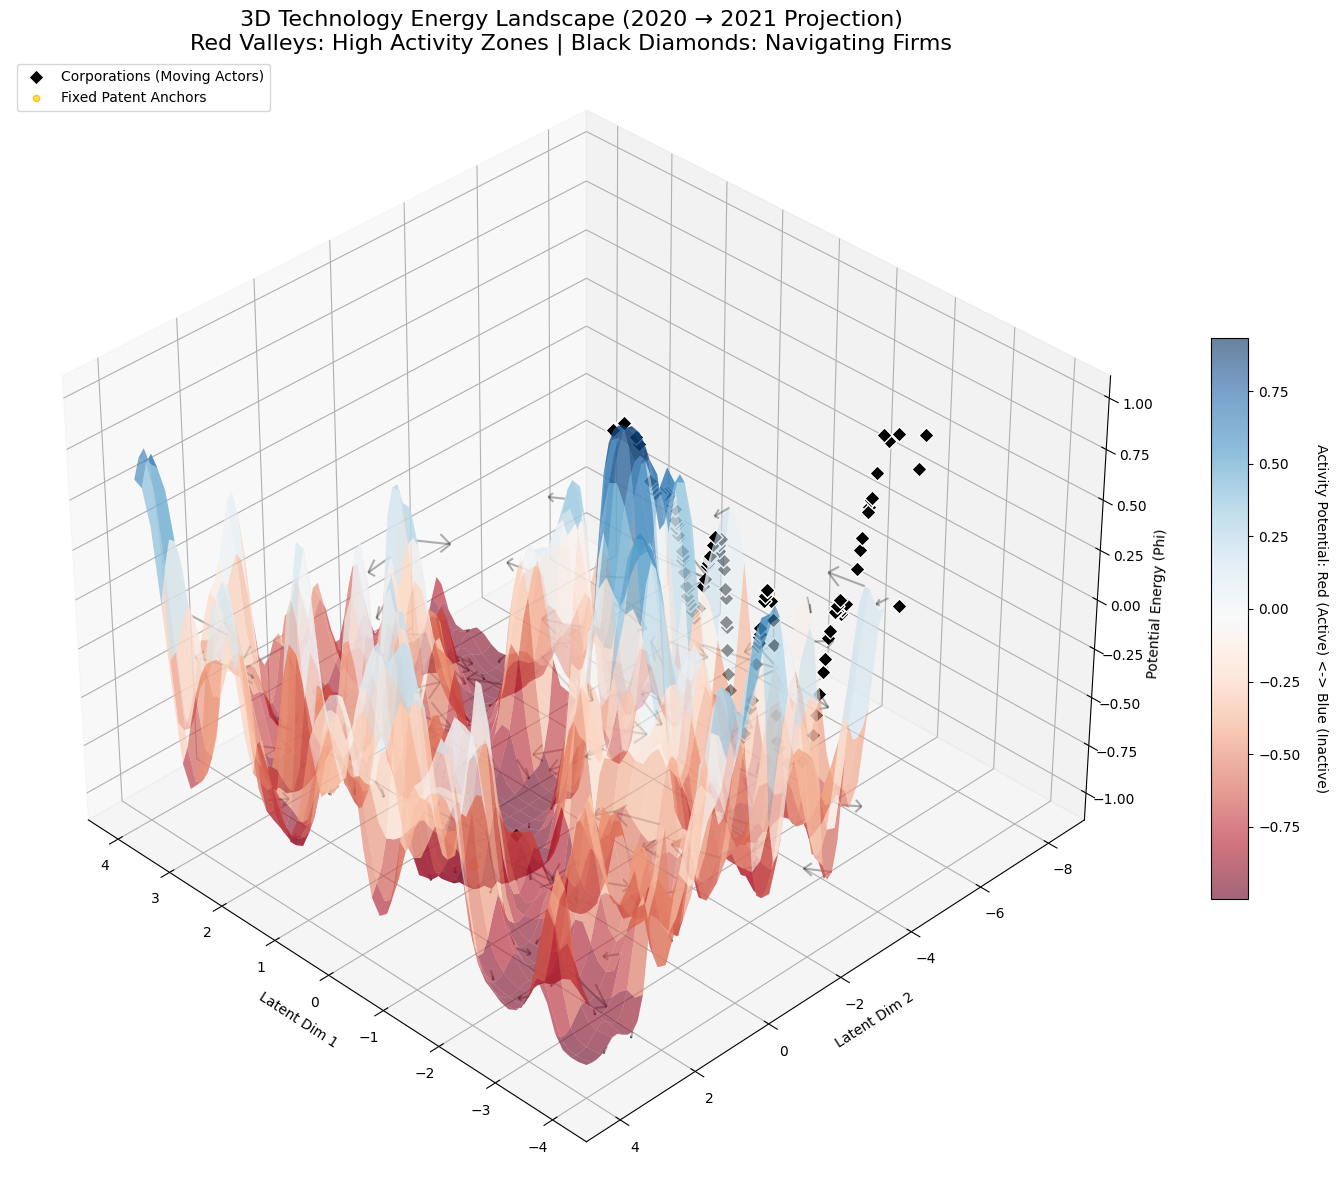

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

def visualize_potential_3d_final(model, data_t, device, res=60, range_lim=4.0):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 年度情報の取得
    current_year = int(data_t.year)
    next_year = current_year + 1

    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャル(Phi)と勾配(-grad Phi)の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z = phi.detach().cpu().numpy().reshape(res, res)
    # 企業の移動を司る引力ベクトル (-grad Phi)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 3. 実際のノード座標を取得
    with torch.no_grad():
        # Hetero変換（未定義エラー回避のため内部で処理を確認）
        h_data = to_hetero_data(data_t, model.num_corps).to(device)
        z, _, _ = model.encode(h_data)
        z_np = z.cpu().numpy()

    # 4. プロット
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 地形：RdBu (低い/谷 = 赤 = 活発 / 高い/山 = 青 = 停滞)
    surf = ax.plot_surface(X, Y, Z, cmap='RdBu', alpha=0.6, 
                           edgecolor='none', antialiased=True, shade=True)

    # --- 企業ノード: 黒い菱形 (移動する主体) ---
    z_corp = z_np[:model.num_corps]
    phi_corp = potential_net(z[:model.num_corps]).detach().cpu().numpy()
    ax.scatter(z_corp[:, 0], z_corp[:, 1], phi_corp,
               color='black', s=60, label='Corporations (Moving Actors)', 
               edgecolors='white', marker='D', depthshade=False)
    
    # --- 特許ノード: 黄色の点 (固定されたアンカー) ---
    active_patents = (np.arange(len(z_np)) >= model.num_corps) & data_t.active_mask.cpu().numpy()
    z_pat = z_np[active_patents]
    phi_pat = potential_net(z[active_patents]).detach().cpu().numpy()
    ax.scatter(z_pat[:, 0], z_pat[:, 1], phi_pat,
               color='gold', s=20, label='Fixed Patent Anchors', 
               alpha=0.7, edgecolors='orange', depthshade=False)

    # --- ベクトル(引力場) ---
    # 企業だけがこの力を受けて谷に吸い込まれる様子を表現
    skip = 5
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z[::skip, ::skip],
              U[::skip, ::skip], V[::skip, ::skip], -0.1, 
              length=0.3, color='black', alpha=0.3, arrow_length_ratio=0.3)

    # 仕上げ
    ax.set_title(f"3D Technology Energy Landscape ({current_year} → {next_year} Projection)\n"
                 f"Red Valleys: High Activity Zones | Black Diamonds: Navigating Firms", fontsize=16)
    ax.set_xlabel("Latent Dim 1")
    ax.set_ylabel("Latent Dim 2")
    ax.set_zlabel("Potential Energy (Phi)")
    ax.view_init(elev=35, azim=135)
    
    cbar = fig.colorbar(surf, shrink=0.5, aspect=15)
    cbar.set_label('Activity Potential: Red (Active) <-> Blue (Inactive)', rotation=270, labelpad=20)
    
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# 実行（最新データを使用）
latest_year = max(graphs.keys())
current_data = graphs[latest_year]
visualize_potential_3d_final(trained_model_gradient_ode, current_data, device)

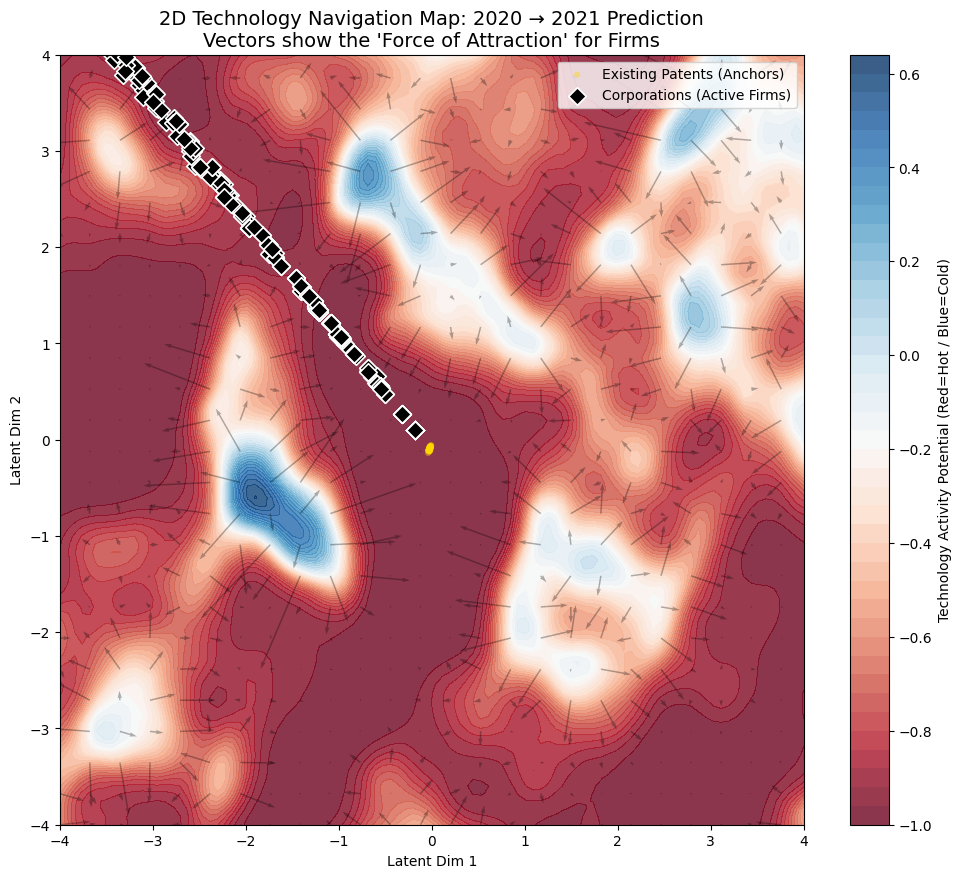

In [61]:
def visualize_potential_2d_quiver(model, data_t, device, res=100, range_lim=4.0):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    l_dim = getattr(model, 'latent_dim', 2)
    current_year = int(data_t.year)
    next_year = current_year + 1

    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if l_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], l_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャルと勾配の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z = phi.detach().cpu().numpy().reshape(res, res)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res) # 引力（下り坂）
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 3. ノード座標の取得
    with torch.no_grad():
        h_data = to_hetero_data(data_t, model.num_corps).to(device)
        z, _, _ = model.encode(h_data)
        z_np = z.cpu().numpy()

    # 4. プロット
    plt.figure(figsize=(12, 10))
    
    # 背景：ポテンシャル地形（赤＝活発な谷、青＝停滞した山）
    contour = plt.contourf(X, Y, Z, levels=50, cmap='RdBu', alpha=0.8)
    plt.colorbar(contour, label='Technology Activity Potential (Red=Hot / Blue=Cold)')

    # ベクトル表記 (Quiver): 1年後の移動予測方向
    # skipで表示密度を調整（見にくい場合はこの値を大きくする）
    skip = 4
    plt.quiver(X[::skip, ::skip], Y[::skip, ::skip], U[::skip, ::skip], V[::skip, ::skip], 
               color='black', alpha=0.3, width=0.002, headwidth=3)

    # 特許分布: 黄色の点 (固定された技術標的)
    active_patents = (np.arange(len(z_np)) >= model.num_corps) & data_t.active_mask.cpu().numpy()
    plt.scatter(z_np[active_patents, 0], z_np[active_patents, 1], 
                color='gold', s=20, alpha=0.4, label='Existing Patents (Anchors)', edgecolors='none')

    # 企業分布: 黒い菱形 (移動する戦略主体)
    plt.scatter(z_np[:model.num_corps, 0], z_np[:model.num_corps, 1], 
                color='black', s=80, label='Corporations (Active Firms)', edgecolors='white', marker='D', linewidth=1.2)

    plt.title(f"2D Technology Navigation Map: {current_year} → {next_year} Prediction\nVectors show the 'Force of Attraction' for Firms", fontsize=14)
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.legend(loc='upper right')
    plt.xlim(-range_lim, range_lim)
    plt.ylim(-range_lim, range_lim)
    plt.show()

# 実行
visualize_potential_2d_quiver(trained_model_gradient_ode, current_data, device)

In [66]:
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import GATConv, HeteroConv
from torchdiffeq import odeint_adjoint as odeint
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    try:
        s = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
        vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
        return vals if len(vals) > 0 else None
    except: return None

def preprocess_data(file_path):
    print(">>> データを読み込み中...")
    # ※実際のデータセットパスに合わせて変更してください
    df = pd.read_csv(file_path)
    valid_indices, combined_vectors = [], []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    df["corporation"] = df["corporation"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df['year_month'] = pd.to_datetime(df['year_month'])
    return df

def build_global_graphs(df):
    all_corps = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    c_map = {corp: i for i, corp in enumerate(all_corps)}
    p_map = {pat: i + len(all_corps) for i, pat in enumerate(all_patents)}
    total_nodes = len(all_corps) + len(all_patents)
    
    patent_features = {row['patent_number']: row['combined_vector'] for _, row in df.iterrows()}
    graphs = {}
    for year, group in df.groupby(df['year_month'].dt.year):
        edges, active_nodes = [], set()
        for _, row in group.iterrows():
            p_idx = p_map[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = c_map[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
        
        x = torch.zeros(total_nodes, len(next(iter(patent_features.values()))))
        for p_num, p_idx in p_map.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
            
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        mask = torch.zeros(total_nodes, dtype=torch.bool)
        mask[list(active_nodes)] = True
        # Dataオブジェクトにyear属性を追加
        graphs[year] = Data(x=x, edge_index=edge_index, active_mask=mask, num_nodes=total_nodes, year=year)
        
    return graphs, len(all_corps), total_nodes

# ============================================================
# 2. モデル定義
# ============================================================
class HeteroVGAEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = HeteroConv({
            ('corp', 'owns', 'patent'): GATConv(in_dim, hidden_dim, add_self_loops=False),
            ('patent', 'owned_by', 'corp'): GATConv(in_dim, hidden_dim, add_self_loops=False)
        }, aggr='sum')
        self.mu_l = nn.ModuleDict({'corp': nn.Linear(hidden_dim, out_dim), 'patent': nn.Linear(hidden_dim, out_dim)})
        self.logvar_l = nn.ModuleDict({'corp': nn.Linear(hidden_dim, out_dim), 'patent': nn.Linear(hidden_dim, out_dim)})

    def forward(self, x_dict, edge_index_dict):
        x = {k: F.elu(v) for k, v in self.conv1(x_dict, edge_index_dict).items()}
        mu = {k: self.mu_l[k](v) for k, v in x.items()}
        logvar = {k: self.logvar_l[k](v) for k, v in x.items()}
        return mu, logvar

class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        # 空間の解像度を上げるためのランダム周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim
        
        # 層を深くし、Dropoutを加えることで一方向の単純な壁になるのを防ぐ
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh() # 出力を -1 から 1 に制限
        )

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net, num_corps):
        super().__init__()
        self.pn = potential_net
        self.num_corps = num_corps

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.pn(z_in)
            grad = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        v = -torch.tanh(grad)
        mask = torch.zeros((z.size(0), 1), device=z.device)
        mask[:self.num_corps, :] = 1.0
        return v * mask

class UnifiedVGAE(nn.Module):
    def __init__(self, num_corps, num_nodes, in_dim, hidden_dim, latent_dim):
        super().__init__()
        self.num_corps, self.num_nodes = num_corps, num_nodes
        self.corp_emb = nn.Embedding(num_corps, in_dim)
        self.encoder = HeteroVGAEEncoder(in_dim, hidden_dim, latent_dim)
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net, num_corps)
        self.bilinear_W = nn.Parameter(torch.randn(latent_dim, latent_dim))
        nn.init.xavier_uniform_(self.bilinear_W)
        self.latent_dim = latent_dim

    def encode(self, h_data):
        x_dict = {'corp': self.corp_emb(torch.arange(self.num_corps, device=device)), 'patent': h_data['patent'].x}
        mu_d, lv_d = self.encoder(x_dict, h_data.edge_index_dict)
        mu = torch.cat([mu_d['corp'], mu_d['patent']], dim=0)
        lv = torch.cat([lv_d['corp'], lv_d['patent']], dim=0)
        z = mu + torch.randn_like(lv) * torch.exp(0.5 * lv) if self.training else mu
        return z, mu, lv

    def decode(self, z, edge_index):
        z_u, z_v = z[edge_index[0]], z[edge_index[1]]
        return torch.sum((z_u @ self.bilinear_W) * z_v, dim=-1)

    def predict_future(self, z, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z.device)
        return odeint(self.ode_func, z, t_span, method='rk4')[-1]

# ============================================================
# 3. ユーティリティ (Loss, Sampling)
# ============================================================
def to_hetero_data(data, num_corps):
    h = HeteroData()
    h['corp'].x, h['patent'].x = data.x[:num_corps], data.x[num_corps:]
    e = data.edge_index
    mask = (e[0] < num_corps) & (e[1] >= num_corps)
    c2p = e[:, mask].clone()
    c2p[1] -= num_corps
    h['corp', 'owns', 'patent'].edge_index = c2p
    h['patent', 'owned_by', 'corp'].edge_index = torch.stack([c2p[1], c2p[0]])
    return h

def sample_hard_negatives(z, pos_edge_index, num_corps, n_samples):
    srcs = torch.randint(0, num_corps, (n_samples,), device=device)
    dsts = torch.randint(num_corps, z.size(0), (n_samples,), device=device)
    return torch.stack([srcs, dsts])

def compute_loss(model, data_t, data_t1, num_corps, margin=0.4):
    h_t = to_hetero_data(data_t, num_corps).to(device)
    z_t, mu_t, lv_t = model.encode(h_t)
    
    # 1. Ranking Loss (t)
    pos_idx = data_t.edge_index
    neg_idx = sample_hard_negatives(z_t, pos_idx, num_corps, n_samples=pos_idx.size(1))
    p_score, n_score = model.decode(z_t, pos_idx), model.decode(z_t, neg_idx)
    recon_loss = F.margin_ranking_loss(p_score, n_score, torch.ones_like(p_score), margin=margin)

    # 2. Smooth Potential Loss
    unique_p, counts = torch.unique(pos_idx[1], return_counts=True)
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    if unique_p.numel() > 0:
        target_phi[unique_p] = -2.0 * (counts.float() / counts.max()).view(-1, 1)
    pot_loss = F.mse_loss(model.potential_net(mu_t)[unique_p], target_phi[unique_p])

    # 3. Future Link Ranking Loss (t+1)
    z_t1_pred = model.predict_future(z_t)
    pos_t1 = data_t1.edge_index
    neg_t1 = sample_hard_negatives(z_t1_pred, pos_t1, num_corps, n_samples=pos_t1.size(1))
    future_loss = F.margin_ranking_loss(model.decode(z_t1_pred, pos_t1), 
                                        model.decode(z_t1_pred, neg_t1), 
                                        torch.ones(pos_t1.size(1), device=device), margin=margin)
    
    reg_loss = torch.norm(model.bilinear_W, p=2) * 0.01
    return recon_loss + pot_loss + future_loss + reg_loss

# ============================================================
# 4. 学習実行
# ============================================================
# データの読み込みとグラフ構築
# ※実際のデータセットパスに合わせて変更してください
df = preprocess_data('../dataset/topic_info3.csv')
graphs, num_corps, total_n = build_global_graphs(df)
years = sorted(graphs.keys())
train_years = years[:int(len(years)*0.8)]

# モデル・最適化 (latent_dim=16 で設定)
model = UnifiedVGAE(num_corps, total_n, in_dim=1088, hidden_dim=128, latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"\n>>> 学習開始 (企業数: {num_corps}, 総ノード数: {total_n}, Latent Dim: {model.latent_dim})")
# デモ用にEpoch数を少なめに設定しています。必要に応じて増やしてください。
for epoch in range(10): 
    model.train()
    epoch_loss = 0
    for i in range(len(train_years)-1):
        data_t, data_t1 = graphs[train_years[i]].to(device), graphs[train_years[i+1]].to(device)
        optimizer.zero_grad()
        loss = compute_loss(model, data_t, data_t1, num_corps)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1:02d} | Total Loss: {epoch_loss:.4f}")

# 学習済みモデルとして保持
trained_model_gradient_ode = model

# ============================================================
# 5. 3Dポテンシャル可視化関数 (修正版)
# ============================================================
def visualize_potential_3d_final(model, data_t, device, res=60, range_lim=4.0):
    model.eval()
    # 修正: モデル構造に合わせてアクセス方法を変更
    potential_net = model.potential_net
    
    # 年度情報の取得
    current_year = int(data_t.year)
    next_year = current_year + 1

    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    # latent_dim > 2 の場合のパディング処理
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャル(Phi)と勾配(-grad Phi)の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z = phi.detach().cpu().numpy().reshape(res, res)
    # 企業の移動を司る引力ベクトル (-grad Phi) の最初の2次元成分
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 3. 実際のノード座標を取得
    with torch.no_grad():
        h_data = to_hetero_data(data_t, model.num_corps).to(device)
        z, _, _ = model.encode(h_data)
        z_np = z.cpu().numpy()

    # 4. プロット
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 地形：RdBu (低い/谷 = 赤 = 活発 / 高い/山 = 青 = 停滞)
    surf = ax.plot_surface(X, Y, Z, cmap='RdBu_r', alpha=0.8, # RdBu_r にして赤を谷(低)にする
                           edgecolor='none', antialiased=True, shade=True)

    # --- 企業ノード: 黒い菱形 (移動する主体) ---
    z_corp = z_np[:model.num_corps]
    # 最初の2次元だけ使用
    phi_corp = potential_net(z[:model.num_corps]).detach().cpu().numpy().flatten()
    ax.scatter(z_corp[:, 0], z_corp[:, 1], phi_corp,
               color='black', s=60, label='Corporations (Moving Actors)', 
               edgecolors='white', marker='D', depthshade=False, zorder=10)
    
    # --- 特許ノード: 黄色の点 (固定されたアンカー) ---
    active_patents_mask = (np.arange(len(z_np)) >= model.num_corps) & data_t.active_mask.cpu().numpy()
    z_pat = z_np[active_patents_mask]
    z_pat_tensor = z[active_patents_mask]
    if len(z_pat) > 0:
        phi_pat = potential_net(z_pat_tensor).detach().cpu().numpy().flatten()
        ax.scatter(z_pat[:, 0], z_pat[:, 1], phi_pat,
                   color='gold', s=30, label='Fixed Patent Anchors', 
                   alpha=0.9, edgecolors='orange', depthshade=False, zorder=10)

    # --- ベクトル(引力場) ---
    # 企業だけがこの力を受けて谷に吸い込まれる様子を表現
    skip = 3 # 間引く数を調整
    # 3D quiver は (x, y, z, u, v, w)
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z[::skip, ::skip],
              U[::skip, ::skip], V[::skip, ::skip], np.zeros_like(Z[::skip, ::skip]), # Z方向のベクトルは0とする
              length=0.2, color='black', alpha=0.5, arrow_length_ratio=0.4)

    # 仕上げ
    ax.set_title(f"3D Technology Energy Landscape ({current_year} -> {next_year} Projection)\n"
                 f"Red Valleys: High Activity Zones | Black Diamonds: Navigating Firms", fontsize=16)
    ax.set_xlabel("Latent Dim 1")
    ax.set_ylabel("Latent Dim 2")
    ax.set_zlabel("Potential Energy (Phi)")
    # 見やすい角度に調整
    ax.view_init(elev=45, azim=-60)
    
    cbar = fig.colorbar(surf, shrink=0.6, aspect=20, pad=0.1)
    cbar.set_label('Potential Energy: Red (Low/Valley) <-> Blue (High/Peak)', rotation=270, labelpad=20)
    
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# ============================================================
# 6. 可視化の実行
# ============================================================
# 最新のデータを使用して可視化
latest_year = max(graphs.keys())
current_data = graphs[latest_year]
visualize_potential_3d_final(trained_model_gradient_ode, current_data, device)

>>> データを読み込み中...

>>> 学習開始 (企業数: 4391, 総ノード数: 47175, Latent Dim: 16)


NotImplementedError: Module [PotentialNet] is missing the required "forward" function